# TCR–pMHC Class I benchmark — figures

Loads the per-model/condition metric CSVs in this directory, plus
`iptm_extracted_v4.csv`, `timing_v2.csv`, and `angle_errors_classI.tsv`
(produced by `../analysis/extract_iptm_v4.py`, `../analysis/extract_timing_v2.py`,
and `../analysis/docking_angle/analyze_angles.py` respectively), and
reproduces the report's Class I figures: DockQ across models/conditions,
rank-0 vs best-of-5, RMSD by region, CDR RMSD, confidence-vs-accuracy
correlations, docking-geometry error, and runtime.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr, wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations

sns.set_theme(style="whitegrid", context="talk")

## Load and merge data

In [2]:
files = [
    "af3_classI_no_msa_no_template.csv",
    "af3_classI_with_msa_no_template.csv",
    "af3_classI_with_msa_with_template.csv",

    "intellifoldv2_classI_no_msa_no_template.csv",
    "intellifoldv2_classI_with_msa_no_template.csv",
    "intellifoldv2_classI_with_msa_with_template.csv",

    "protenixv1_classI_no_msa_no_template.csv",
    "protenixv1_classI_with_msa_no_template.csv",
    "protenixv1_classI_with_msa_with_template.csv",

    "protenixv2_classI_no_msa_no_template.csv",
    "protenixv2_classI_with_msa_no_template.csv",
    "protenixv2_classI_with_msa_with_template.csv",
]

dfs = {}
for file in files:
    model_name = file.replace(".csv", "")
    df = pd.read_csv(file, sep="\t")
    df["model"] = model_name
    dfs[model_name] = df

all_df = pd.concat(dfs.values(), ignore_index=True)
print("all_df:", all_df.shape, "| unique targets:", all_df["id"].nunique())

all_df: (3360, 35) | unique targets: 56


In [3]:
# Merge keys used to join the confidence/timing/angle tables below
all_df["model_family"] = all_df["model"].str.extract(r"^(af3|intellifoldv2|protenixv1|protenixv2)")
all_df["condition"] = all_df["model"].str.extract(
    r"classI_(no_msa_no_template|with_msa_no_template|with_msa_with_template)"
)
all_df["target"] = all_df["id"] + "_pmhc_tcr"
all_df["sample"] = all_df["rank"].str.replace("ranked_", "", regex=False).astype(int)

# Short, plot-friendly model/condition labels
name_map = {
    "af3_classI_no_msa_no_template": "AF3 | noMSA noTemp",
    "af3_classI_with_msa_no_template": "AF3 | MSA",
    "af3_classI_with_msa_with_template": "AF3 | MSA+Temp",

    "intellifoldv2_classI_no_msa_no_template": "IF2 | noMSA noTemp",
    "intellifoldv2_classI_with_msa_no_template": "IF2 | MSA",
    "intellifoldv2_classI_with_msa_with_template": "IF2 | MSA+Temp",

    "protenixv1_classI_no_msa_no_template": "PTXv1 | noMSA noTemp",
    "protenixv1_classI_with_msa_no_template": "PTXv1 | MSA",
    "protenixv1_classI_with_msa_with_template": "PTXv1 | MSA+Temp",

    "protenixv2_classI_no_msa_no_template": "PTXv2 | noMSA noTemp",
    "protenixv2_classI_with_msa_no_template": "PTXv2 | MSA",
    "protenixv2_classI_with_msa_with_template": "PTXv2 | MSA+Temp",
}
all_df["model_short"] = all_df["model"].map(name_map)

short_model_order = [
    "AF3 | MSA+Temp", "AF3 | MSA", "AF3 | noMSA noTemp",
    "IF2 | MSA+Temp", "IF2 | MSA", "IF2 | noMSA noTemp",
    "PTXv1 | MSA+Temp", "PTXv1 | MSA", "PTXv1 | noMSA noTemp",
    "PTXv2 | MSA+Temp", "PTXv2 | MSA", "PTXv2 | noMSA noTemp",
]

# Use ranked_0 (top-ranked prediction) for the main model comparisons
rank0_df = all_df[all_df["rank"] == "ranked_0"].copy()

In [4]:
# Confidence scores (iPTM/pTM) and wall-clock timing, extracted separately
timing_df = pd.read_csv("timing_v2.csv")
more_metrics_df = pd.read_csv("iptm_extracted_v4.csv")

# iptm_extracted_v4.csv uses different model-family spellings than the
# per-model CSVs above (e.g. "protenix_v1" vs "protenixv1") - align them
# before merging.
model_fix = {
    "intellifold2": "intellifoldv2",
    "protenix_v1": "protenixv1",
    "protenix_v2": "protenixv2",
    "af3": "af3",
}
more_tmp = more_metrics_df.rename(columns={"model": "model_family"}).copy()
more_tmp["model_family"] = more_tmp["model_family"].replace(model_fix)

merge_keys = ["model_family", "condition", "target", "sample"]
merged_df = all_df.merge(more_tmp, on=merge_keys, how="left", suffixes=("", "_more"))
print("Matched confidence-score rows:", merged_df["iptm"].notna().sum(), "/", len(merged_df))

rank0_merged_df = merged_df[merged_df["rank"] == "ranked_0"].copy()

Matched confidence-score rows: 3360 / 3360


## Figure — DockQ distribution across models and conditions

/tmp/ipykernel_1355310/608922070.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_1355310/608922070.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([


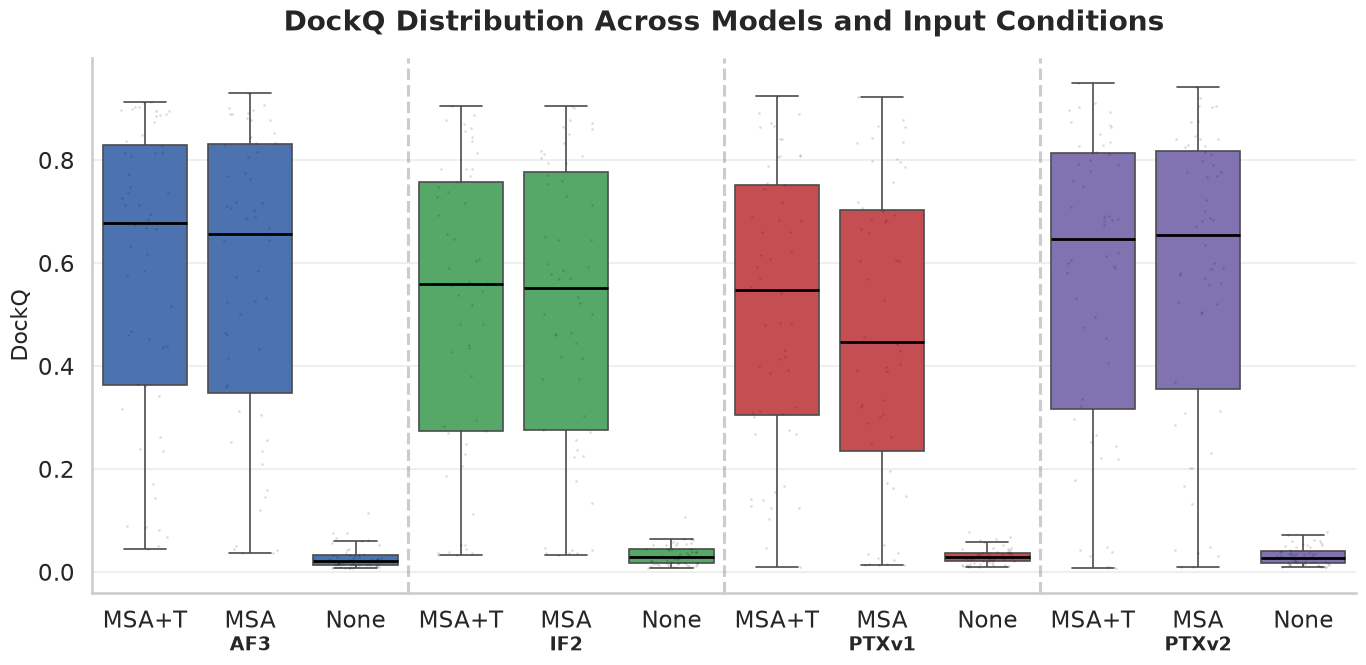

In [5]:
palette = [
    "#4C72B0", "#4C72B0", "#4C72B0",      # AF3
    "#55A868", "#55A868", "#55A868",      # IF2
    "#C44E52", "#C44E52", "#C44E52",      # PTXv1
    "#8172B2", "#8172B2", "#8172B2"       # PTXv2
]

plt.figure(figsize=(14,7))

ax = sns.boxplot(
    data=rank0_merged_df,
    x="model_short",
    y="DockQ",
    order=short_model_order,
    showfliers=False,
    palette=palette,
    saturation=1,          # <- keeps the exact hex colors, no desaturation
    linewidth=1.2,
    medianprops=dict(color="black", linewidth=2)
)

sns.stripplot(
    data=rank0_merged_df,
    x="model_short",
    y="DockQ",
    order=short_model_order,
    color="black",
    alpha=0.15,
    size=1.8,
    jitter=0.25
)

# Family separators
for xpos in [2.5, 5.5, 8.5]:
    plt.axvline(x=xpos, color="gray", linestyle="--", alpha=0.4)

# Short labels
ax.set_xticklabels([
    "MSA+T", "MSA", "None",
    "MSA+T", "MSA", "None",
    "MSA+T", "MSA", "None",
    "MSA+T", "MSA", "None"
])

# Family labels
family_centers = [1, 4, 7, 10]
family_names = ["AF3", "IF2", "PTXv1", "PTXv2"]

for x, name in zip(family_centers, family_names):
    ax.text(x, -0.08, name, ha="center", va="top", fontsize=14,
            fontweight="bold", transform=ax.get_xaxis_transform())

ax.set_ylabel("DockQ", fontsize=16)
ax.set_xlabel("")
ax.set_title("DockQ Distribution Across Models and Input Conditions",
             fontsize=20, fontweight="bold", pad=20)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Figure — rank-0 vs best-of-5 DockQ

In [6]:
best5_df = (
    merged_df.loc[merged_df.groupby(["model_short", "id"])["DockQ"].idxmax()]
    .copy()
)

comparison = pd.DataFrame({
    "Rank 0": rank0_merged_df.groupby("model_short")["DockQ"].mean(),
    "Best of 5": best5_df.groupby("model_short")["DockQ"].mean(),
}).reset_index()

/tmp/ipykernel_1355310/1437624256.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([


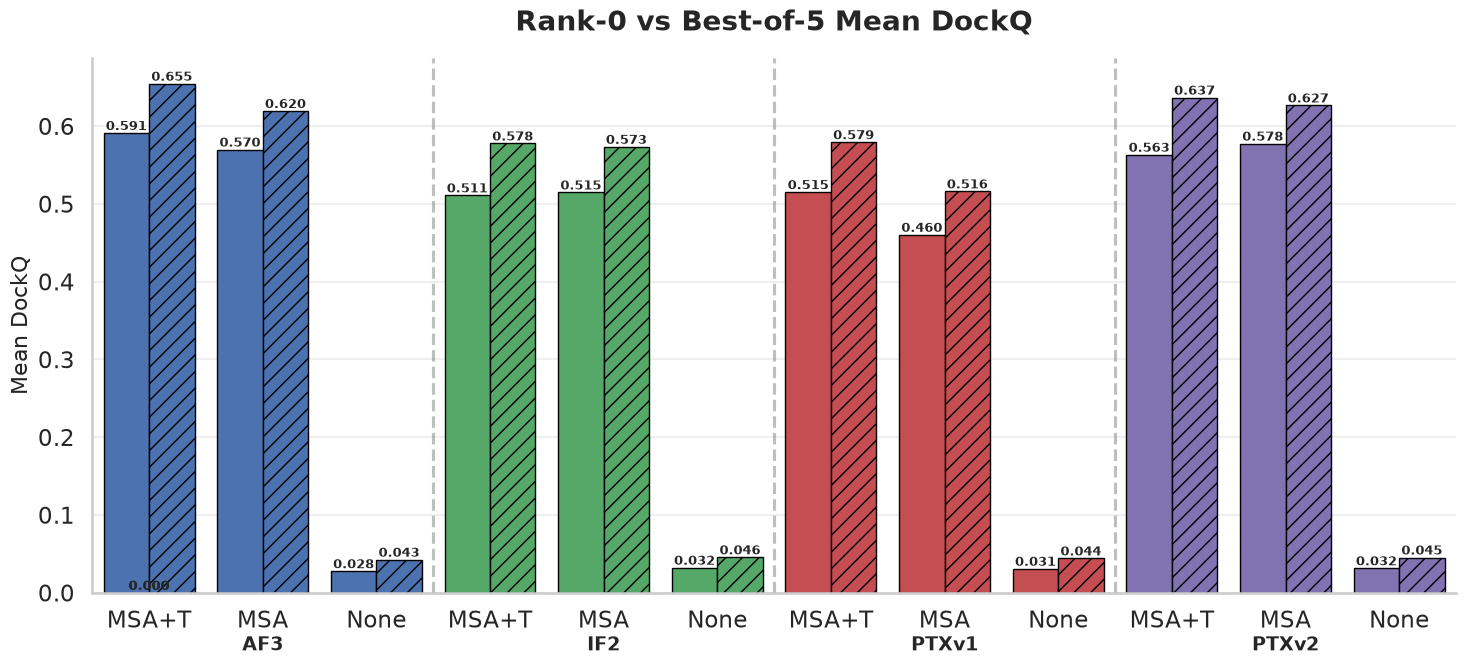

In [7]:
comparison_long = comparison.melt(id_vars="model_short", var_name="Selection", value_name="DockQ")
comparison_long["model_short"] = pd.Categorical(
    comparison_long["model_short"], categories=short_model_order, ordered=True
)
comparison_long = comparison_long.sort_values("model_short")

palette = [
    "#4C72B0", "#4C72B0", "#4C72B0",      # AF3
    "#55A868", "#55A868", "#55A868",      # IF2
    "#C44E52", "#C44E52", "#C44E52",      # PTXv1
    "#8172B2", "#8172B2", "#8172B2"       # PTXv2
]

plt.figure(figsize=(15,7))

ax = sns.barplot(
    data=comparison_long, x="model_short", y="DockQ", hue="Selection",
    edgecolor="black", linewidth=1
)

# Map hatch patterns to distinguish rank0 vs best-of-5
hatch_map = {}
hatches_cycle = ["", "//"]  # first selection = solid, second = hatched
for i, sel in enumerate(comparison_long["Selection"].unique()):
    hatch_map[sel] = hatches_cycle[i % len(hatches_cycle)]

# ax.containers groups bars by hue level; within each container, bars are in x order
for container, sel in zip(ax.containers, comparison_long["Selection"].unique()):
    for bar, color in zip(container, palette):
        bar.set_facecolor(color)
        bar.set_hatch(hatch_map[sel])
        bar.set_edgecolor("black")
        bar.set_linewidth(1)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width()/2, h),
                ha="center", va="bottom", fontsize=9, fontweight="bold")

for xpos in [2.5, 5.5, 8.5]:
    ax.axvline(xpos, color="gray", linestyle="--", alpha=0.5)

ax.set_xticklabels([
    "MSA+T", "MSA", "None",
    "MSA+T", "MSA", "None",
    "MSA+T", "MSA", "None",
    "MSA+T", "MSA", "None"
])

family_centers = [1, 4, 7, 10]
family_names = ["AF3", "IF2", "PTXv1", "PTXv2"]
for x, name in zip(family_centers, family_names):
    ax.text(x, -0.08, name, ha="center", va="top", fontsize=14,
            fontweight="bold", transform=ax.get_xaxis_transform())

ax.set_ylabel("Mean DockQ", fontsize=16)
ax.set_xlabel("")
ax.set_title("Rank-0 vs Best-of-5 Mean DockQ", fontsize=20, fontweight="bold", pad=20)
ax.get_legend().remove()
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Figure — RMSD by region (global, TCR, pMHC)

/tmp/ipykernel_1355310/2215154712.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([


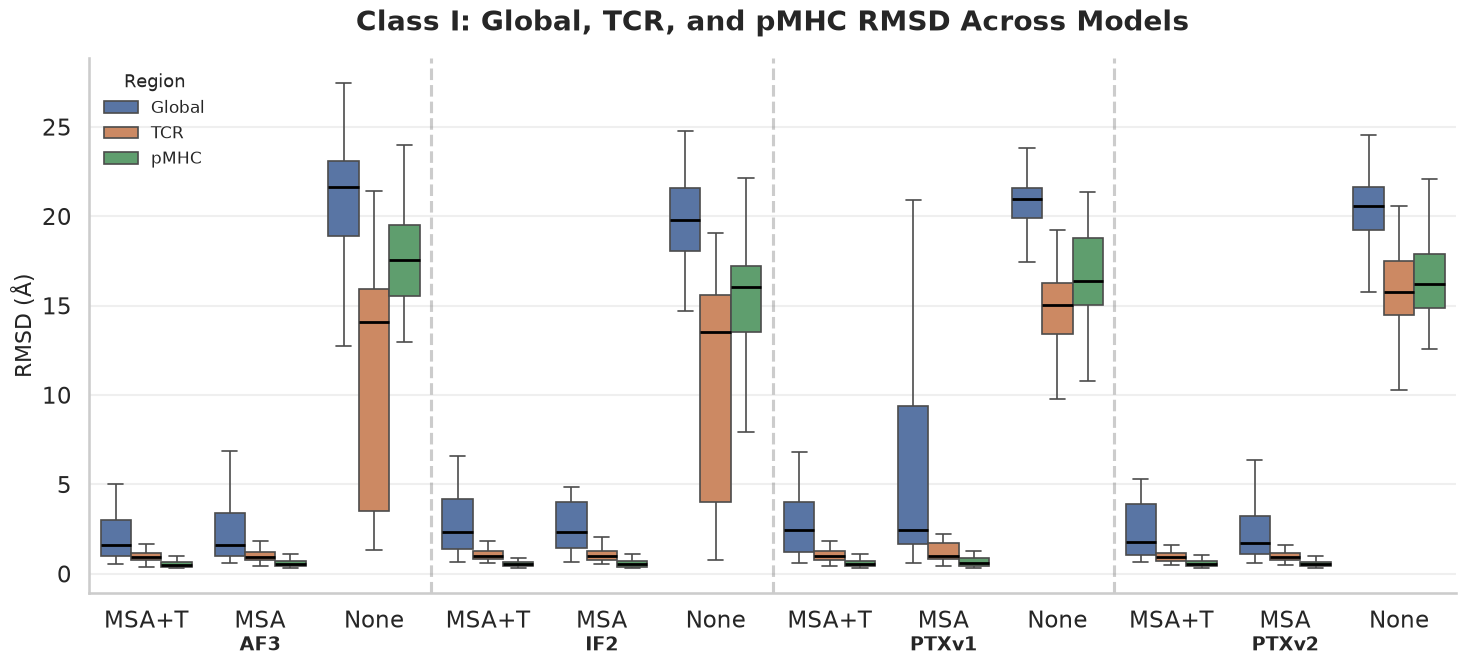

In [8]:
rmsd_metrics = ["RMSD", "RMSD-tcr", "RMSD-pmhc"]

rmsd_long = rank0_df.melt(
    id_vars=["id", "model_short"], value_vars=rmsd_metrics,
    var_name="metric", value_name="RMSD_value"
)
metric_labels = {"RMSD": "Global", "RMSD-tcr": "TCR", "RMSD-pmhc": "pMHC"}
rmsd_long["metric"] = rmsd_long["metric"].map(metric_labels)

plt.figure(figsize=(15,7))

ax = sns.boxplot(
    data=rmsd_long, x="model_short", y="RMSD_value", hue="metric",
    order=short_model_order, showfliers=False, linewidth=1.2,
    medianprops=dict(color="black", linewidth=2)
)

for xpos in [2.5, 5.5, 8.5]:
    ax.axvline(xpos, color="gray", linestyle="--", alpha=0.4)

ax.set_xticklabels([
    "MSA+T", "MSA", "None",
    "MSA+T", "MSA", "None",
    "MSA+T", "MSA", "None",
    "MSA+T", "MSA", "None"
])

family_centers = [1, 4, 7, 10]
family_names = ["AF3", "IF2", "PTXv1", "PTXv2"]
for x, name in zip(family_centers, family_names):
    ax.text(x, -0.08, name, ha="center", va="top", fontsize=14,
            fontweight="bold", transform=ax.get_xaxis_transform())

ax.set_ylabel("RMSD (Å)", fontsize=16)
ax.set_xlabel("")
ax.set_title("Class I: Global, TCR, and pMHC RMSD Across Models",
             fontsize=20, fontweight="bold", pad=20)
ax.legend(title="Region", frameon=False, fontsize=12, title_fontsize=13)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Figure — median CDR RMSD across models

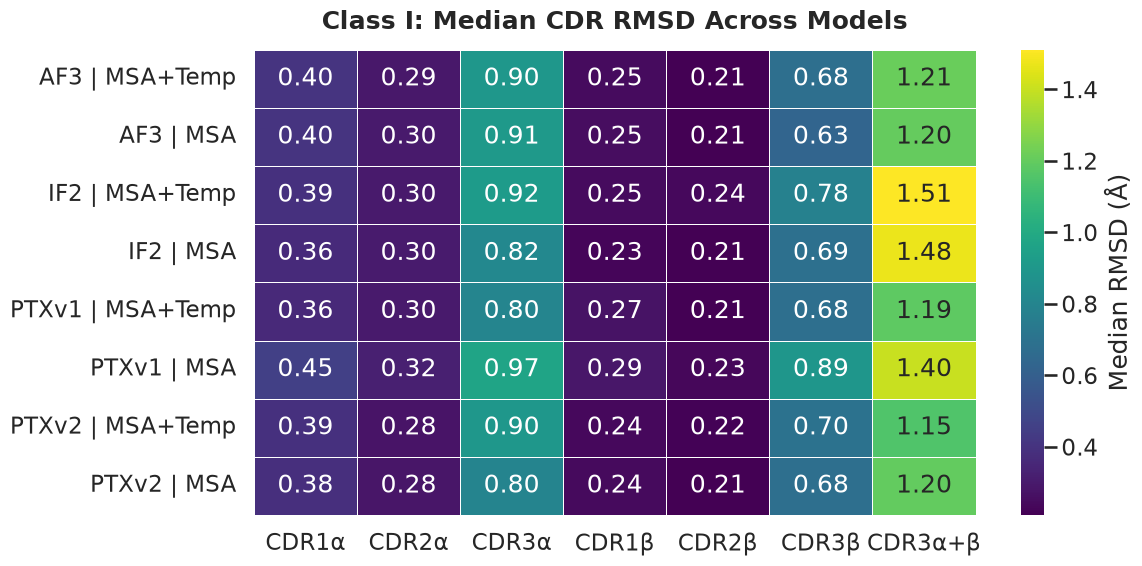

In [9]:
cdr_rmsd_cols = [
    "RMSD-cdr1a", "RMSD-cdr2a", "RMSD-cdr3a",
    "RMSD-cdr1b", "RMSD-cdr2b", "RMSD-cdr3b",
    "RMSD-cdr3a+cdr3b",
]
cdr_labels = ["CDR1α", "CDR2α", "CDR3α", "CDR1β", "CDR2β", "CDR3β", "CDR3α+β"]

# remove no-MSA models: CDR loops aren't meaningfully modeled without an MSA
order_no_nomsa = [m for m in short_model_order if "noMSA" not in m]

cdr_heatmap = (
    rank0_df.groupby("model_short")[cdr_rmsd_cols].median().reindex(order_no_nomsa)
)
cdr_heatmap.columns = cdr_labels

plt.figure(figsize=(12,6))
sns.heatmap(cdr_heatmap, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5,
            cbar_kws={"label": "Median RMSD (Å)"})
plt.title("Class I: Median CDR RMSD Across Models", fontsize=18, fontweight="bold", pad=15)
plt.xlabel(""); plt.ylabel("")
plt.xticks(rotation=0); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Figure — relative CDR accuracy across models (z-score per region)

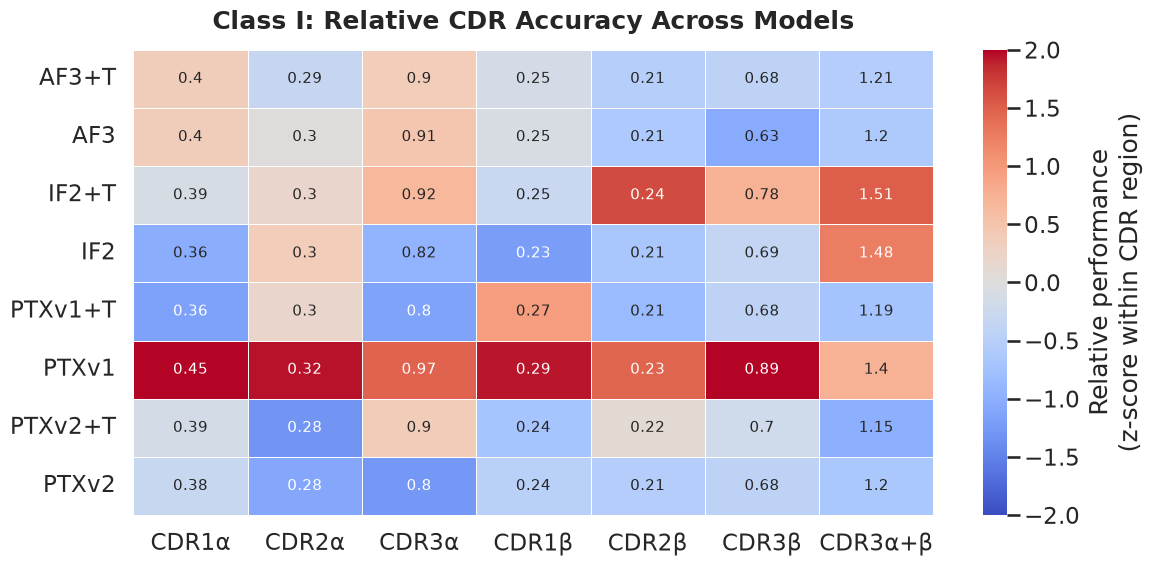

In [10]:
# Same medians as above, re-expressed as a per-region z-score so models can
# be compared independently of how difficult each CDR region is in general.
cdr_heatmap_z_input = cdr_heatmap.copy()
cdr_heatmap_z_input.index = ["AF3+T", "AF3", "IF2+T", "IF2", "PTXv1+T", "PTXv1", "PTXv2+T", "PTXv2"]

cdr_z = (cdr_heatmap_z_input - cdr_heatmap_z_input.mean(axis=0)) / cdr_heatmap_z_input.std(axis=0)

plt.figure(figsize=(12,6))
sns.heatmap(
    cdr_z, annot=cdr_heatmap_z_input.round(2), fmt="", cmap="coolwarm",
    center=0, vmin=-2, vmax=2, linewidths=0.5, annot_kws={"fontsize":11},
    cbar_kws={"label": "Relative performance\n(z-score within CDR region)"}
)
plt.title("Class I: Relative CDR Accuracy Across Models", fontsize=18, fontweight="bold", pad=15)
plt.xlabel(""); plt.ylabel("")
plt.xticks(rotation=0); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Figure — DockQ vs iPTM by model family

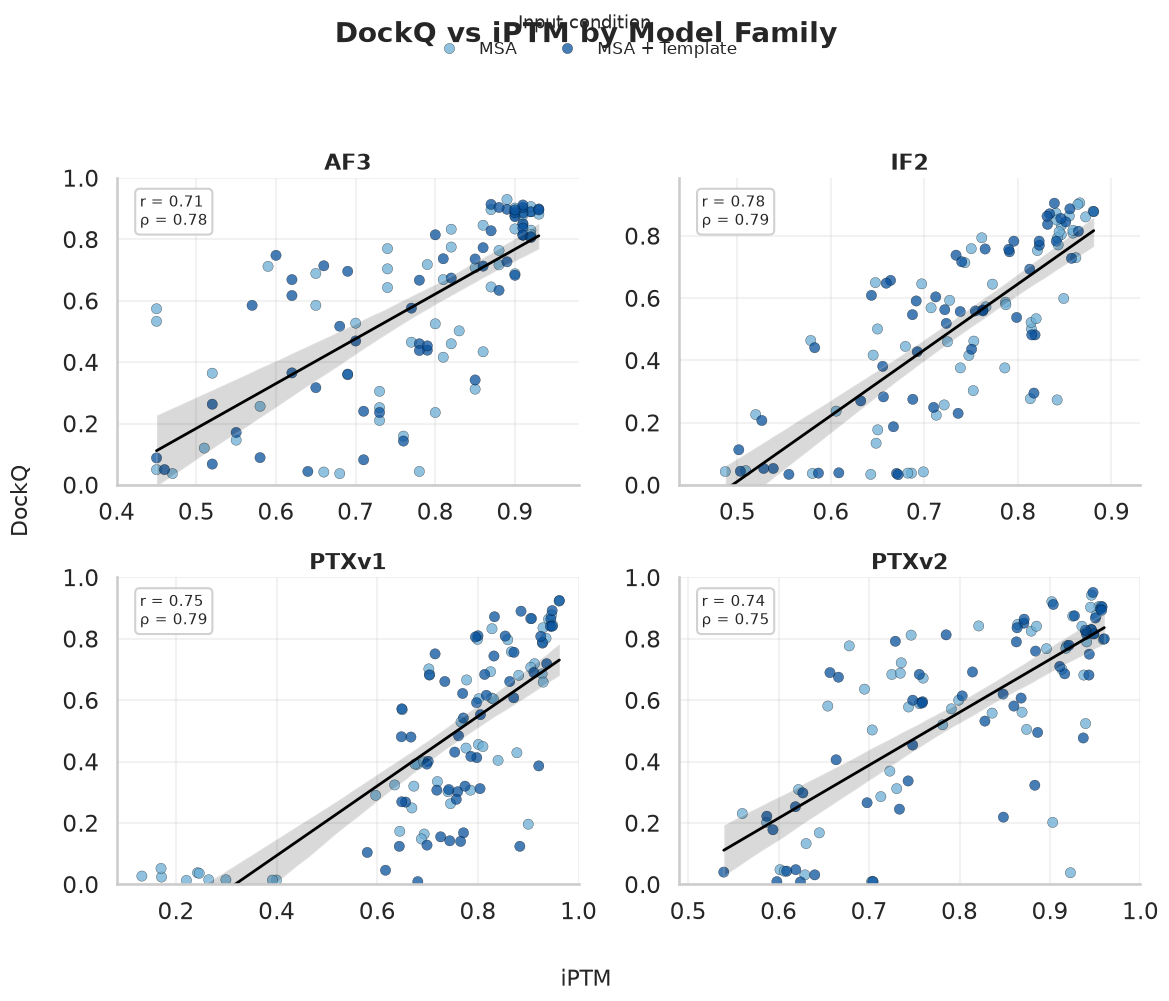

In [11]:
plot_df = rank0_merged_df[~rank0_merged_df["model_short"].str.contains("noMSA")].copy()
plot_df["family"] = plot_df["model_short"].str.split(" | ", regex=False).str[0]

condition_map = {"with_msa_no_template": "MSA", "with_msa_with_template": "MSA + Template"}
plot_df["condition_short"] = plot_df["condition"].map(condition_map)

palette = {"MSA": "#6BAED6", "MSA + Template": "#08519C"}
families = ["AF3", "IF2", "PTXv1", "PTXv2"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=False, sharey=False)

for ax, fam in zip(axes.flatten(), families):
    sub = plot_df[plot_df["family"] == fam].copy()

    sns.scatterplot(data=sub, x="iptm", y="DockQ", hue="condition_short", palette=palette,
                     alpha=0.75, s=55, edgecolor="black", linewidth=0.25, ax=ax)
    sns.regplot(data=sub, x="iptm", y="DockQ", scatter=False, color="black",
                line_kws={"linewidth": 2}, ax=ax)

    r, _ = pearsonr(sub["iptm"], sub["DockQ"])
    rho, _ = spearmanr(sub["iptm"], sub["DockQ"])
    ax.text(0.05, 0.95, f"r = {r:.2f}\nρ = {rho:.2f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.9))

    ax.set_title(fam, fontsize=16, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")

    x_min, x_max = sub["iptm"].min(), sub["iptm"].max()
    y_min, y_max = sub["DockQ"].min(), sub["DockQ"].max()
    ax.set_xlim(max(0, x_min - 0.05), min(1.0, x_max + 0.05))
    ax.set_ylim(max(0, y_min - 0.08), min(1.0, y_max + 0.08))

    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.grid(axis="both", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Input condition", loc="upper center", ncol=2,
           frameon=False, fontsize=12, title_fontsize=13)
fig.supxlabel("iPTM", fontsize=16)
fig.supylabel("DockQ", fontsize=16)
plt.suptitle("DockQ vs iPTM by Model Family", fontsize=20, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Figure — CDR3αβ RMSD vs CDR3αβ pLDDT by model family

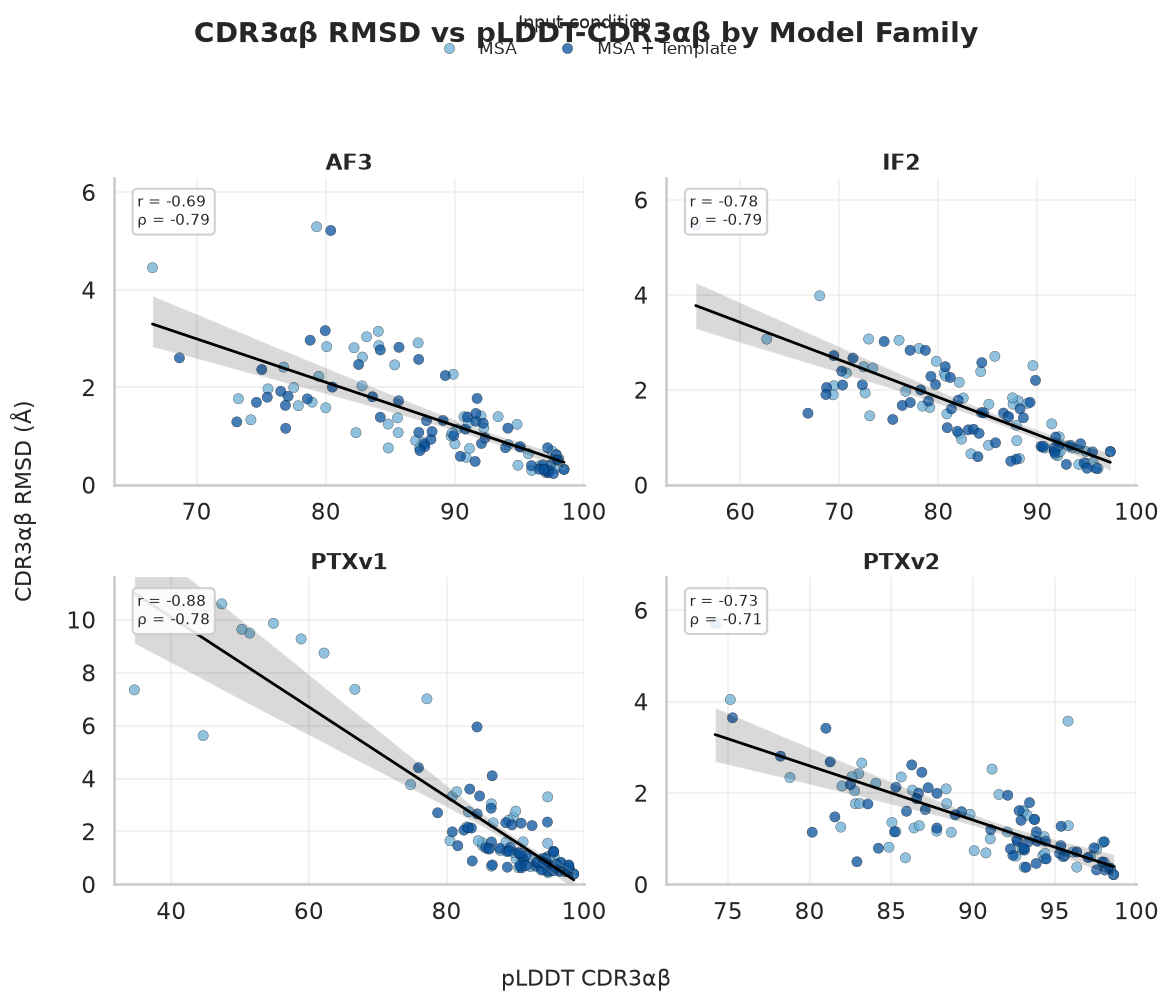

In [12]:
plot_df = rank0_merged_df[~rank0_merged_df["model_short"].str.contains("noMSA")].copy()
plot_df["family"] = plot_df["model_short"].str.split(" | ", regex=False).str[0]
plot_df["condition_short"] = plot_df["condition"].map(condition_map)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=False, sharey=False)

for ax, fam in zip(axes.flatten(), families):
    sub = plot_df[plot_df["family"] == fam].copy()

    sns.scatterplot(data=sub, x="pLDDT-cdr3a+cdr3b", y="RMSD-cdr3a+cdr3b",
                     hue="condition_short", palette=palette, alpha=0.75, s=55,
                     edgecolor="black", linewidth=0.25, ax=ax)
    sns.regplot(data=sub, x="pLDDT-cdr3a+cdr3b", y="RMSD-cdr3a+cdr3b", scatter=False,
                color="black", line_kws={"linewidth": 2}, ax=ax)

    r, _ = pearsonr(sub["pLDDT-cdr3a+cdr3b"], sub["RMSD-cdr3a+cdr3b"])
    rho, _ = spearmanr(sub["pLDDT-cdr3a+cdr3b"], sub["RMSD-cdr3a+cdr3b"])
    ax.text(0.05, 0.95, f"r = {r:.2f}\nρ = {rho:.2f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8", alpha=0.9))

    ax.set_title(fam, fontsize=16, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")

    x_min, x_max = sub["pLDDT-cdr3a+cdr3b"].min(), sub["pLDDT-cdr3a+cdr3b"].max()
    y_min, y_max = sub["RMSD-cdr3a+cdr3b"].min(), sub["RMSD-cdr3a+cdr3b"].max()
    ax.set_xlim(max(0, x_min - 3), min(100, x_max + 3))
    ax.set_ylim(max(0, y_min - 0.5), y_max + 1)

    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.grid(axis="both", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Input condition", loc="upper center", ncol=2,
           frameon=False, fontsize=12, title_fontsize=13)
fig.supxlabel("pLDDT CDR3αβ", fontsize=16)
fig.supylabel("CDR3αβ RMSD (Å)", fontsize=16)
plt.suptitle("CDR3αβ RMSD vs pLDDT-CDR3αβ by Model Family", fontsize=20, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Docking geometry — load and merge angle data

In [13]:
# Docking/incident angle errors, computed separately (see
# ../analysis/docking_angle/) and merged onto the same per-target metrics.
angle_df = pd.read_csv("angle_errors_classI.tsv", sep="\t")
angle_df = angle_df.rename(columns={"pdb": "id"})

angle_model_map = {
    "af3": "af3",
    "intellifold2": "intellifoldv2",
    "protenix_v1": "protenixv1",
    "protenix_v2": "protenixv2",
}
angle_condition_map = {
    "msa": "with_msa_no_template",
    "msa+tmpl": "with_msa_with_template",
}
angle_df["model_family"] = angle_df["model"].map(angle_model_map)
angle_df["condition_mapped"] = angle_df["condition"].map(angle_condition_map)
angle_df["model_full"] = angle_df["model_family"] + "_classI_" + angle_df["condition_mapped"]

angle_merged = angle_df.merge(
    all_df, left_on=["id", "model_full", "rank"], right_on=["id", "model", "rank"],
    how="left", suffixes=("_angle", "")
)

angle_rank0 = angle_merged[
    (angle_merged["rank"] == "ranked_0")
    & (angle_merged["status"] == "OK")
    & (angle_merged["DockQ"].notna())
].copy()
print("angle_rank0:", angle_rank0.shape, "| unique targets:", angle_rank0["id"].nunique())

model_name_map = {
    "af3": "AF3", "intellifoldv2": "IntelliFold2",
    "protenixv1": "Protenix v1", "protenixv2": "Protenix v2",
}
angle_condition_label_map = {"with_msa_no_template": "MSA", "with_msa_with_template": "MSA + template"}

angle_rank0["model_label"] = angle_rank0["model_family"].map(model_name_map)
angle_rank0["condition_label"] = angle_rank0["condition"].astype(str).str.strip().map(angle_condition_label_map)

angle_model_order = ["AF3", "IntelliFold2", "Protenix v1", "Protenix v2"]
angle_condition_order = ["MSA", "MSA + template"]

angle_rank0: (440, 52) | unique targets: 56


## Figure — native vs. predicted docking geometry

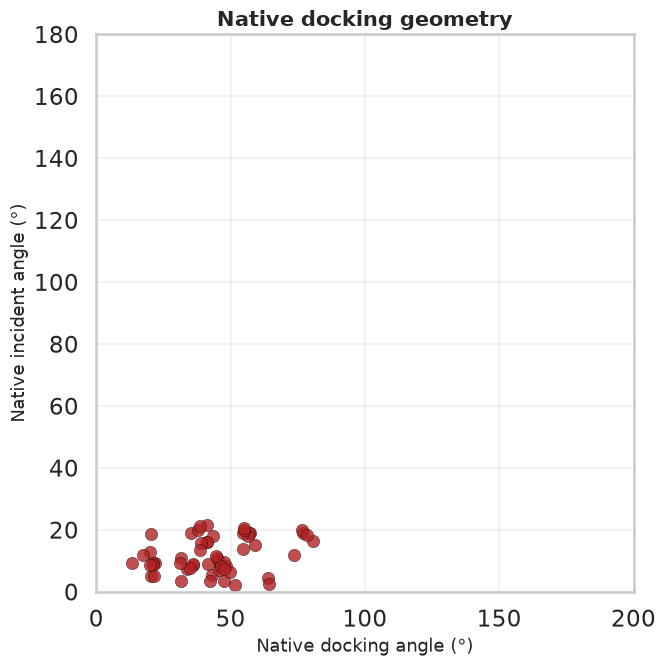

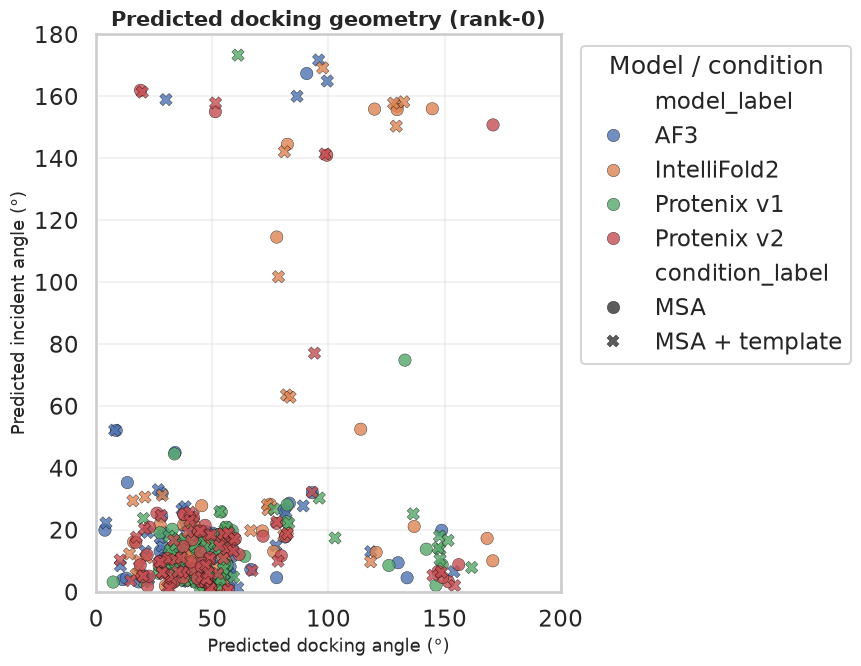

In [14]:
plot_df_native = angle_rank0.drop_duplicates(subset="id")[["id", "dock_native", "inc_native"]].copy()

plt.figure(figsize=(7, 7))
sns.scatterplot(data=plot_df_native, x="dock_native", y="inc_native",
                 color="firebrick", s=80, alpha=0.8, edgecolor="black", linewidth=0.3)
plt.xlim(0, 200); plt.ylim(0, 180)
plt.xlabel("Native docking angle (°)", fontsize=13)
plt.ylabel("Native incident angle (°)", fontsize=13)
plt.title("Native docking geometry", fontsize=15, fontweight="bold")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.scatterplot(data=angle_rank0, x="dock_pred", y="inc_pred",
                 hue="model_label", hue_order=angle_model_order,
                 style="condition_label", style_order=angle_condition_order,
                 s=80, alpha=0.8, edgecolor="black", linewidth=0.3)
plt.xlim(0, 200); plt.ylim(0, 180)
plt.xlabel("Predicted docking angle (°)", fontsize=13)
plt.ylabel("Predicted incident angle (°)", fontsize=13)
plt.title("Predicted docking geometry (rank-0)", fontsize=15, fontweight="bold")
plt.legend(title="Model / condition", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Figure — docking/incident angle error across models

/tmp/ipykernel_1355310/1516529399.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=angle_rank0, x="model_label", y=metric, hue="condition_label",


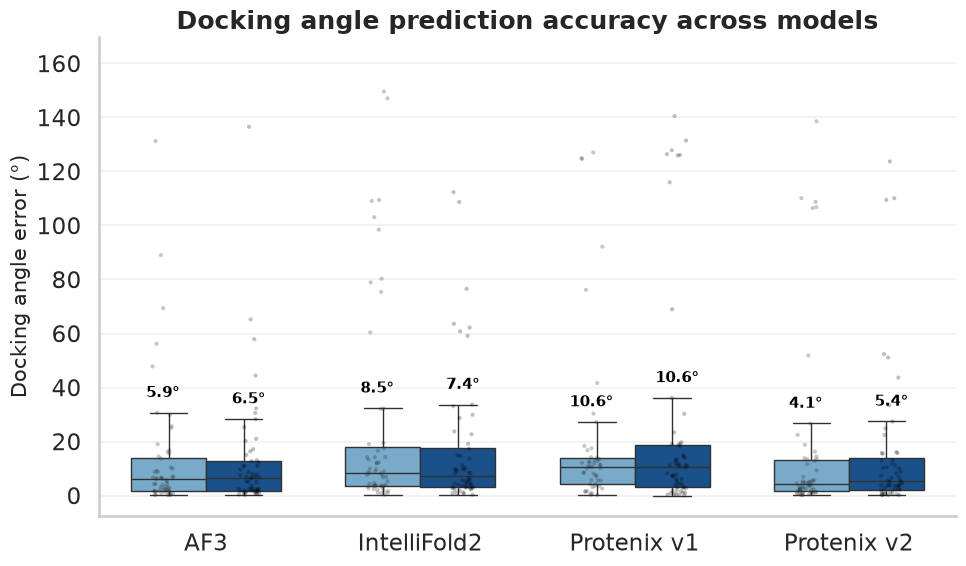

/tmp/ipykernel_1355310/1516529399.py:17: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=angle_rank0, x="model_label", y=metric, hue="condition_label",


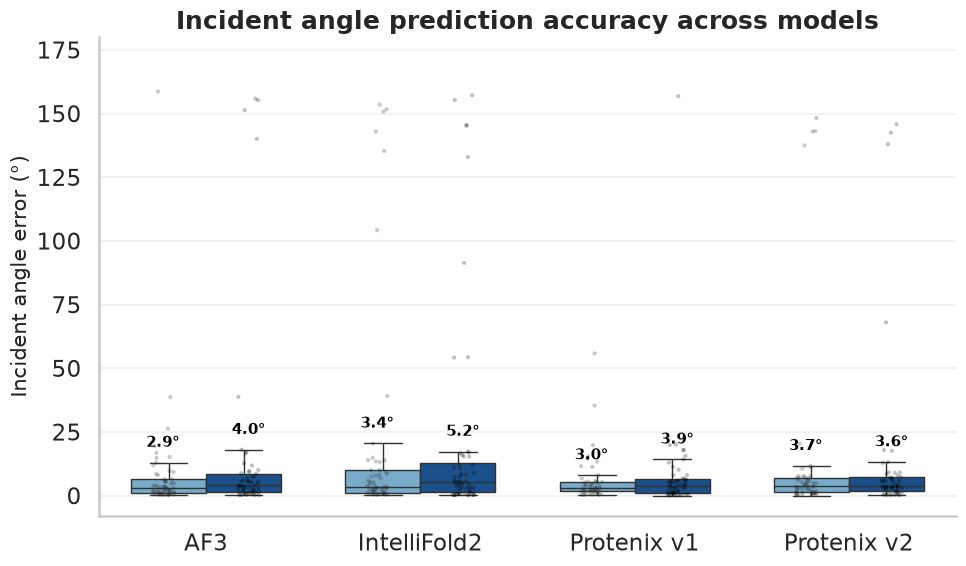

In [15]:
def upper_whisker(x):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    upper_cap = q3 + 1.5 * iqr
    return x[x <= upper_cap].max()

angle_palette = {"MSA": "#6BAED6", "MSA + template": "#08519C"}

for metric, ylabel, title in [
    ("dock_err", "Docking angle error (°)", "Docking angle prediction accuracy across models"),
    ("inc_err", "Incident angle error (°)", "Incident angle prediction accuracy across models"),
]:
    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(data=angle_rank0, x="model_label", y=metric, hue="condition_label",
                      order=angle_model_order, hue_order=angle_condition_order,
                      palette=angle_palette, showfliers=False, width=0.7)
    sns.stripplot(data=angle_rank0, x="model_label", y=metric, hue="condition_label",
                  order=angle_model_order, hue_order=angle_condition_order, dodge=True,
                  alpha=0.25, size=3, color="black", legend=False)

    medians = angle_rank0.groupby(["model_label", "condition_label"])[metric].median()
    whiskers = angle_rank0.groupby(["model_label", "condition_label"])[metric].apply(upper_whisker)
    y_range = angle_rank0[metric].max() - angle_rank0[metric].min()
    label_gap = y_range * 0.03

    for i, model in enumerate(angle_model_order):
        for j, condition in enumerate(angle_condition_order):
            median_value = medians.loc[(model, condition)]
            whisker_top = whiskers.loc[(model, condition)]
            x_pos = i - 0.20 + j * 0.40
            ax.text(x_pos, whisker_top + label_gap, f"{median_value:.1f}°",
                    ha="center", va="bottom", fontsize=11, fontweight="bold", color="black")

    ax.set_ylim(ax.get_ylim()[0], ax.get_ylim()[1] * 1.08)
    if ax.legend_ is not None:
        ax.legend_.remove()
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_title(title, fontsize=18, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

## Statistical tests — pairwise Wilcoxon signed-rank, Holm-corrected

In [16]:
def run_pairwise_wilcoxon(df, metric, condition):
    sub = df[df["condition_label"] == condition].copy()
    results = []
    for m1, m2 in combinations(angle_model_order, 2):
        d1 = sub[sub["model_label"] == m1][["id", metric]].rename(columns={metric: "v1"})
        d2 = sub[sub["model_label"] == m2][["id", metric]].rename(columns={metric: "v2"})
        merged = d1.merge(d2, on="id", how="inner")
        stat, p = wilcoxon(merged["v1"], merged["v2"])
        results.append({
            "condition": condition, "metric": metric, "model_1": m1, "model_2": m2,
            "n": len(merged), "wilcoxon_stat": stat, "p_raw": p,
            "median_1": merged["v1"].median(), "median_2": merged["v2"].median()
        })
    results = pd.DataFrame(results)
    reject, p_holm, _, _ = multipletests(results["p_raw"], method="holm")
    results["p_holm"] = p_holm
    results["significant"] = reject
    return results.sort_values("p_holm")

all_results = []
for metric in ["dock_err", "inc_err"]:
    for condition in angle_condition_order:
        all_results.append(run_pairwise_wilcoxon(angle_rank0, metric, condition))

all_results = pd.concat(all_results, ignore_index=True)
all_results

,condition,metric,model_1,model_2,n,wilcoxon_stat,p_raw,median_1,median_2,p_holm,significant
0,MSA,dock_err,AF3,IntelliFold2,56,500.0,0.023685,5.940,8.465,0.142107,False
1,MSA,dock_err,AF3,Protenix v1,48,387.0,0.038955,4.685,10.585,0.160312,False
2,MSA,dock_err,Protenix v1,Protenix v2,48,379.0,0.032062,10.585,4.085,0.160312,False
3,MSA,dock_err,IntelliFold2,Protenix v2,56,592.0,0.092887,8.465,4.085,0.278662,False
4,MSA,dock_err,IntelliFold2,Protenix v1,48,542.0,0.643630,8.465,10.585,1.000000,False
5,MSA,dock_err,AF3,Protenix v2,56,727.0,0.562486,5.940,4.085,1.000000,False
6,MSA + template,dock_err,AF3,Protenix v1,56,535.0,0.031927,6.500,10.550,0.191563,False
7,MSA + template,dock_err,Protenix v1,Protenix v2,56,584.0,0.080878,10.550,5.390,0.404388,False
8,MSA + template,dock_err,AF3,Protenix v2,56,750.0,0.695398,6.500,5.390,0.896846,False
9,MSA + template,dock_err,AF3,IntelliFold2,56,649.0,0.224211,6.500,7.375,0.896846,False


## Geometrically atypical predictions vs. DockQ

A prediction is a "geometry outlier" if its docking angle or incident angle
falls outside the range spanned by the 56 native structures.

In [17]:
native_max_inc = angle_rank0.drop_duplicates(subset="id")["inc_native"].max()
native_max_dock = angle_rank0.drop_duplicates(subset="id")["dock_native"].max()
native_min_dock = angle_rank0.drop_duplicates(subset="id")["dock_native"].min()

print(f"Native incident angle range: 0 - {native_max_inc:.1f}°")
print(f"Native docking angle range: {native_min_dock:.1f} - {native_max_dock:.1f}°")

angle_rank0["is_geometry_outlier"] = (
    (angle_rank0["inc_pred"] > native_max_inc)
    | (angle_rank0["dock_pred"] > native_max_dock)
    | (angle_rank0["dock_pred"] < native_min_dock)
)

outlier_frac = angle_rank0.groupby("model_label")["is_geometry_outlier"].mean() * 100
print("\nGeometry outlier fraction (%) by model - incident OR docking angle outside native range:")
print(outlier_frac.round(1))

print("\nDockQ distribution, outlier vs non-outlier predictions:")
angle_rank0.groupby("is_geometry_outlier")["DockQ"].describe()

Native incident angle range: 0 - 21.6°
Native docking angle range: 13.4 - 80.8°

Geometry outlier fraction (%) by model - incident OR docking angle outside native range:
model_label
AF3             27.7
IntelliFold2    27.7
Protenix v1     23.1
Protenix v2     25.9
Name: is_geometry_outlier, dtype: float64

DockQ distribution, outlier vs non-outlier predictions:


,count,mean,std,min,25%,50%,75%,max
is_geometry_outlier,,,,,,,,
False,325.0,0.634649,0.221215,0.008,0.482,0.684,0.8160,0.951
True,115.0,0.300322,0.274949,0.009,0.049,0.202,0.4745,0.906


## Figure — mean runtime per model and condition

In [18]:
# Mean runtime per model/condition (Class I only)
timing_classI = timing_df[timing_df["mhc_class"] == "classI"].copy()

runtime_model_map = {"af3": "AF3", "intellifold2": "IF2", "protenix_v1": "PTXv1", "protenix_v2": "PTXv2"}
runtime_condition_map = {
    "no_msa_no_template": "No MSA",
    "with_msa_no_template": "MSA",
    "with_msa_with_template": "MSA + Template",
}
timing_classI["model_label"] = timing_classI["model"].map(runtime_model_map)
timing_classI["condition_label"] = timing_classI["condition"].map(runtime_condition_map)

timing_summary = (
    timing_classI.groupby(["model_label", "condition_label"])["total_minutes"]
    .mean()
    .reset_index(name="mean_runtime_min")
)
timing_summary

,model_label,condition_label,mean_runtime_min
0,AF3,MSA,43.341018
1,AF3,MSA + Template,58.167214
2,AF3,No MSA,2.892643
3,IF2,MSA,11.467571
4,IF2,MSA + Template,10.880946
5,IF2,No MSA,9.786571
6,PTXv1,MSA,1.116411
7,PTXv1,MSA + Template,1.049339
8,PTXv1,No MSA,0.795714
9,PTXv2,MSA,1.390429


/tmp/ipykernel_1355310/27375128.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


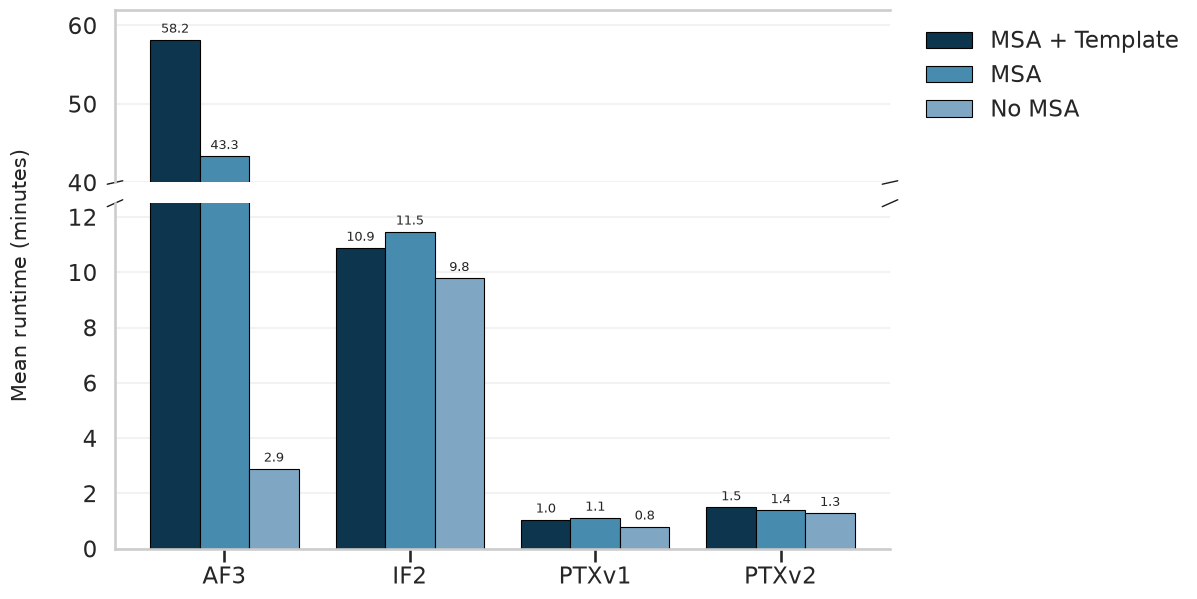

In [19]:
runtime_model_order = ["AF3", "IF2", "PTXv1", "PTXv2"]
runtime_condition_order = ["MSA + Template", "MSA", "No MSA"]
runtime_palette = {"No MSA": "#74A9CF", "MSA": "#3690C0", "MSA + Template": "#023858"}

# Broken y-axis: AF3's runtime is 4-5x the other models', so a single linear
# axis would compress the low values into an unreadable strip near zero.
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(10, 7), gridspec_kw={"height_ratios": [1, 2], "hspace": 0.08}
)

for ax in (ax_top, ax_bot):
    sns.barplot(
        data=timing_summary, x="model_label", y="mean_runtime_min", hue="condition_label",
        order=runtime_model_order, hue_order=runtime_condition_order, palette=runtime_palette,
        edgecolor="black", linewidth=0.8, ax=ax
    )

ax_top.set_ylim(40, 62)
ax_bot.set_ylim(0, 12.5)

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(labeltop=False, bottom=False)
ax_bot.xaxis.tick_bottom()

d = 0.010
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

for container in ax_top.containers:
    ax_top.bar_label(container, fmt="%.1f", fontsize=9, padding=3)
for container in ax_bot.containers:
    ax_bot.bar_label(container, fmt="%.1f", fontsize=9, padding=3)

ax_bot.get_legend().remove()
ax_top.legend(title="", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

ax_bot.set_xlabel("")
fig.text(0.02, 0.5, "Mean runtime (minutes)", va="center", rotation="vertical", fontsize=15)
ax_top.set_ylabel(""); ax_bot.set_ylabel("")
ax_top.grid(axis="y", alpha=0.25); ax_bot.grid(axis="y", alpha=0.25)
ax_top.spines["right"].set_visible(False); ax_bot.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()